# 04. Business Overview

## Objective

Establish a company-level understanding of the business before answering individual business questions.

This notebook works exclusively with `trip_analytical_dataset` — the single source of truth built in `03_build_trip_analytical_dataset.ipynb`.

At this stage:

- overall Revenue, Fuel Cost, Gross Profit, Gross Margin
- trends over time (monthly, yearly)
- revenue by client and by truck
- delay impact on profitability, revisited from Notebook 03

This notebook does not answer any specific business question — it establishes how the business performs overall, as a foundation for the four business-question notebooks that follow.

In [1]:
import os
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from dotenv import load_dotenv
from sqlalchemy import create_engine, text

%matplotlib inline
plt.rcParams["figure.figsize"] = (10, 4)

In [2]:
# Load environment variables
load_dotenv()

DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")

engine = create_engine(
    f"mysql+pymysql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}",
    pool_pre_ping=True,
    future=True
)

try:
    with engine.connect() as connection:
        connection.execute(text("SELECT 1"))
    print("✅ Successfully connected to MySQL.")
except Exception as e:
    print(f"❌ Connection failed:\n{e}")

✅ Successfully connected to MySQL.


### Load Input Data

`trip_analytical_dataset` is read directly from MySQL — the table written back at the end of `03_build_trip_analytical_dataset.ipynb`.

In [3]:
trip_analytical_dataset = pd.read_sql(
    text("SELECT * FROM trip_analytical_dataset"),
    engine,
    parse_dates=["date_departure", "date_arrival"]
)

print(f"Rows loaded: {len(trip_analytical_dataset):,}")

trip_analytical_dataset.head()

Rows loaded: 4,925


,trip_id,date_departure,date_arrival,status,client_id,client_name,client_region,route_id,origin_city,destination_city,...,driver_commission_rate,cargo_tons_actual,load_factor_pct,delay_hours,revenue_uah,estimated_fuel_liters,fuel_cost_uah,batches_used,gross_profit_uah,gross_margin_pct
0,TRP-00001,2022-07-01,2022-07-02,completed,CLT-02,ПП ДніпроЗерно,Дніпропетровська,RTE-02,Дніпро,Одеса,...,0.13,20.76,86.5,1.8,18715.5552,239.59,12985.78,FB-001,5729.7752,30.6
1,TRP-00002,2022-07-01,2022-07-01,completed,CLT-09,ФГ Золоте Колосся,Хмельницька,RTE-09,Хмельницький,Тернопіль,...,0.13,16.44,68.5,1.5,3829.8624,56.85,3081.27,FB-001,748.5924,19.5
2,TRP-00003,2022-07-01,2022-07-01,completed,CLT-09,ФГ Золоте Колосся,Хмельницька,RTE-09,Хмельницький,Тернопіль,...,0.13,16.74,68.3,1.1,3899.7504,54.93,2977.21,FB-001,922.5404,23.7
3,TRP-00004,2022-07-01,2022-07-01,delayed,CLT-08,ТОВ Пшеничний Шлях,Чернігівська,RTE-08,Чернігів,Київ,...,0.13,24.47,99.9,2.1,6526.3937,73.07,3960.39,FB-001,2566.0037,39.3
4,TRP-00005,2022-07-01,2022-07-01,completed,CLT-07,ФГ Жнива-Поділля,Вінницька,RTE-07,Вінниця,Жмеринка,...,0.13,19.47,79.5,0.4,1883.1384,25.50,1382.10,FB-001,501.0384,26.6


## Overall KPIs

Revenue, fuel cost, gross profit, and gross margin across the full observation period. Cancelled trips and rows with unresolved fuel cost (trailing trips after a truck's last recorded refuel) are excluded from these totals — they are analytical gaps, not business volume.

In [4]:
valid_trips = trip_analytical_dataset.dropna(subset=["revenue_uah", "fuel_cost_uah"])

total_revenue = valid_trips["revenue_uah"].sum()
total_fuel_cost = valid_trips["fuel_cost_uah"].sum()
total_gross_profit = total_revenue - total_fuel_cost
gross_margin_pct = total_gross_profit / total_revenue * 100

print(f"Trips included: {len(valid_trips):,} of {len(trip_analytical_dataset):,}")
print(f"Total Revenue:      {total_revenue:,.0f} UAH")
print(f"Total Fuel Cost:    {total_fuel_cost:,.0f} UAH")
print(f"Total Gross Profit: {total_gross_profit:,.0f} UAH")
print(f"Gross Margin:       {gross_margin_pct:.1f}%")

Trips included: 4,827 of 4,925
Total Revenue:      58,202,763 UAH
Total Fuel Cost:    24,398,793 UAH
Total Gross Profit: 33,803,970 UAH
Gross Margin:       58.1%


## Trend Over Time

Revenue, fuel cost, and gross margin by month — the core view for understanding whether rising fuel prices eroded profitability over the observation period.

In [5]:
monthly = (
    valid_trips
    .assign(month=valid_trips["date_departure"].dt.to_period("M").dt.to_timestamp())
    .groupby("month")
    .agg(
        revenue_uah=("revenue_uah", "sum"),
        fuel_cost_uah=("fuel_cost_uah", "sum"),
    )
)
monthly["gross_margin_pct"] = (
    (monthly["revenue_uah"] - monthly["fuel_cost_uah"]) / monthly["revenue_uah"] * 100
)

monthly.head()

,revenue_uah,fuel_cost_uah,gross_margin_pct
month,,,
2022-07-01,2.680230e+06,1260099.63,52.985396
2022-08-01,2.576482e+06,1153936.41,55.212709
2022-09-01,2.501304e+06,1077342.24,56.928784
2022-10-01,2.807782e+06,1196362.00,57.391214
2022-11-01,2.700854e+06,1168216.89,56.746384


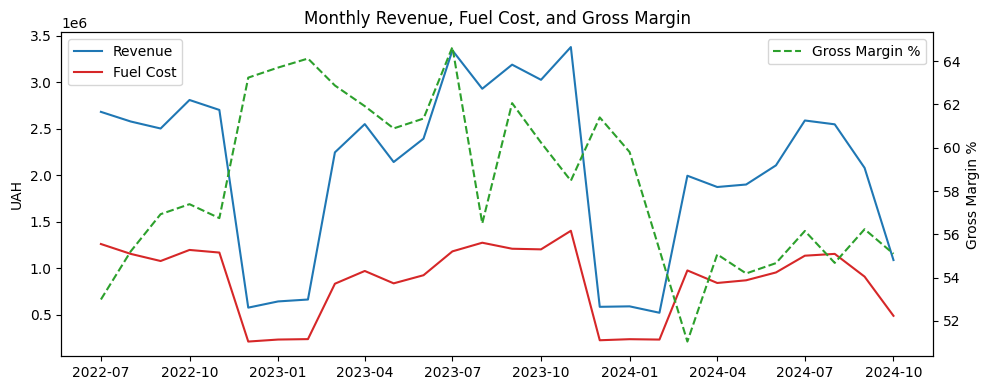

In [6]:
fig, ax1 = plt.subplots()

ax1.plot(monthly.index, monthly["revenue_uah"], label="Revenue", color="tab:blue")
ax1.plot(monthly.index, monthly["fuel_cost_uah"], label="Fuel Cost", color="tab:red")
ax1.set_ylabel("UAH")
ax1.legend(loc="upper left")

ax2 = ax1.twinx()
ax2.plot(monthly.index, monthly["gross_margin_pct"], label="Gross Margin %", color="tab:green", linestyle="--")
ax2.set_ylabel("Gross Margin %")
ax2.legend(loc="upper right")

plt.title("Monthly Revenue, Fuel Cost, and Gross Margin")
plt.tight_layout()
plt.show()

### Yearly Rollup

In [7]:
yearly = (
    valid_trips
    .assign(year=valid_trips["date_departure"].dt.year)
    .groupby("year")
    .agg(
        trip_count=("trip_id", "count"),
        revenue_uah=("revenue_uah", "sum"),
        fuel_cost_uah=("fuel_cost_uah", "sum"),
    )
)
yearly["gross_profit_uah"] = yearly["revenue_uah"] - yearly["fuel_cost_uah"]
yearly["gross_margin_pct"] = yearly["gross_profit_uah"] / yearly["revenue_uah"] * 100

yearly

,trip_count,revenue_uah,fuel_cost_uah,gross_profit_uah,gross_margin_pct
year,,,,,
2022,1296,1.384302e+07,6067823.81,7.775193e+06,56.166898
2023,2169,2.707725e+07,10531934.90,1.654531e+07,61.104114
2024,1362,1.728250e+07,7799034.62,9.483465e+06,54.873226


## Revenue by Client

Top clients by total revenue — a first look at concentration before the dedicated client profitability analysis (Business Question 1).

In [9]:
revenue_by_client = (
    valid_trips
    .groupby("client_name")["revenue_uah"]
    .sum()
    .sort_values(ascending=False)
)

revenue_by_client.head(10)

client_name
ТОВ Полтавські Лани     1.398205e+07
ПП ДніпроЗерно          1.335551e+07
ТОВ Соняшник-Агро       9.953361e+06
АгроЛогістика Центр     8.468531e+06
ТОВ Соєвий Дім          2.801623e+06
ФГ Кукурудза Південь    2.591096e+06
ТОВ Нива Експорт        2.298880e+06
ТОВ Пшеничний Шлях      2.234302e+06
ФГ Золоте Колосся       1.726930e+06
ФГ Жнива-Поділля        7.904753e+05
Name: revenue_uah, dtype: float64

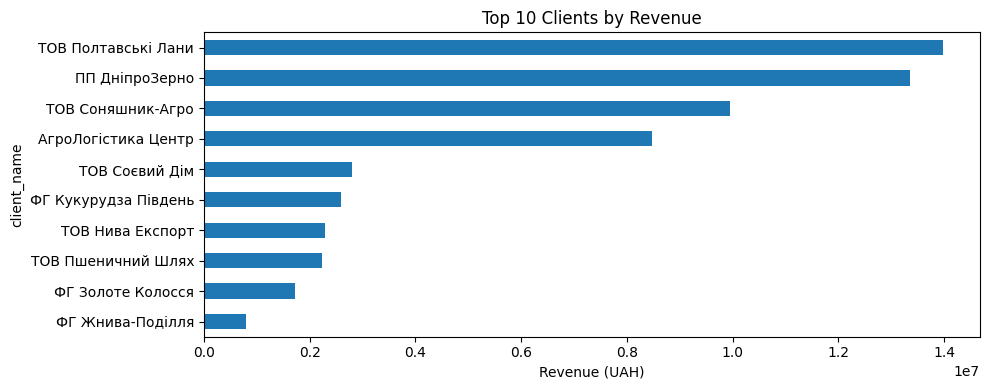

In [10]:
revenue_by_client.head(10).sort_values().plot(kind="barh", color="tab:blue")
plt.xlabel("Revenue (UAH)")
plt.title("Top 10 Clients by Revenue")
plt.tight_layout()
plt.show()

## Revenue by Truck

Fleet-level view — full breakdown follows in the truck and driver performance analysis (Business Question 4).

In [11]:
revenue_by_truck = (
    valid_trips
    .groupby("truck_id")["revenue_uah"]
    .sum()
    .sort_values(ascending=False)
)

revenue_by_truck

truck_id
TRK-04    6.704066e+06
TRK-08    6.620674e+06
TRK-06    5.777950e+06
TRK-05    5.630682e+06
TRK-09    5.447121e+06
TRK-11    4.922311e+06
TRK-07    4.329631e+06
TRK-12    4.257151e+06
TRK-02    3.994617e+06
TRK-10    3.951285e+06
TRK-03    3.457146e+06
TRK-01    3.110128e+06
Name: revenue_uah, dtype: float64

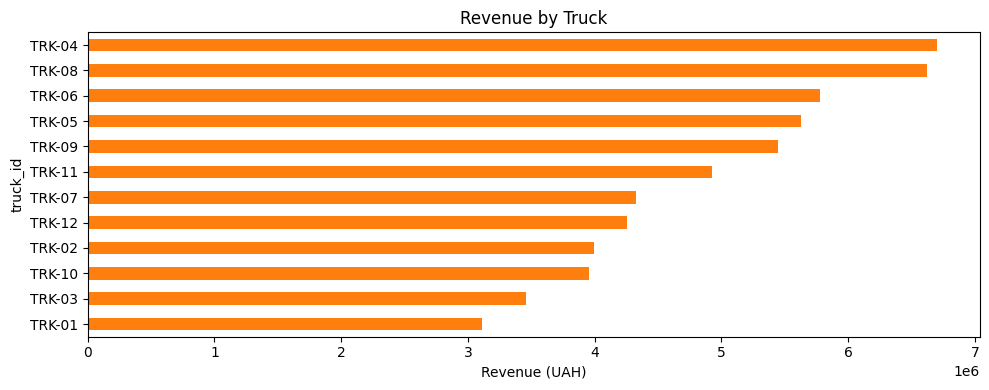

In [12]:
revenue_by_truck.sort_values().plot(kind="barh", color="tab:orange")
plt.xlabel("Revenue (UAH)")
plt.title("Revenue by Truck")
plt.tight_layout()
plt.show()

## Delay Impact on Profitability

Revisiting the finding from `03_build_trip_analytical_dataset.ipynb`: delayed trips are consistently less profitable than completed trips, driven by idle fuel consumption during delays.

In [13]:
valid_trips.groupby("status")["gross_margin_pct"].agg(["mean", "median", "count"])

,mean,median,count
status,,,
completed,58.752365,60.1,4186
delayed,51.829485,54.3,641


## Summary

**Business Understanding — key takeaways before moving to individual business questions:**

- The company operates at a healthy overall gross margin across the observation period (see Overall KPIs above).
- Revenue shows strong seasonality, peaking during the harvest months (roughly July–October) and dropping sharply in winter — consistent with the client base's seasonal grain-shipping demand. Gross margin rises during the winter dip, since fuel cost falls faster than revenue when volume is low.
- Revenue is heavily concentrated in a small number of top clients, with the largest client generating roughly 10x the revenue of the smallest client in the top 10 — this motivates a closer look in the client profitability analysis (Business Question 1).
- Revenue is more evenly distributed across trucks than across clients, suggesting fleet utilization is not the primary driver of the revenue concentration seen above — the truck and driver performance analysis (Business Question 4) will confirm whether this holds for profitability as well.
- Delayed trips are consistently less profitable than completed trips (58.8% vs 51.8% mean gross margin), due to idle fuel consumption during delays — this motivates a closer look at delay-heavy routes in Business Question 3.

This dataset and these baseline figures are the reference point for all four business-question notebooks that follow.